In [528]:
import numpy as np
from engioptiqa import AnnealingSolverAmplify, TrussStructure, TrussStructureOptimization

In [529]:
token_dict = {'fixstars': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Fixstars.txt'}
proxy='http://proxy.ilsb.tuwien.ac.at:3128'
annealing_solver_gpu = AnnealingSolverAmplify(client_type='fixstars', token_file=token_dict['fixstars'], proxy=proxy)
annealing_solver_gpu.setup_solver()

Setting default timeout (ms): 800
Created solver


In [530]:
ts_opt = TrussStructureOptimization()

In [531]:
ts_opt.add_node(0, (0,0))  # Node 0 at (0,0)
ts_opt.add_node(1, (1,0))  # Node 1 at (1,0)
ts_opt.add_node(2, (1,1))  # Node 2 at (1,1)
ts_opt.add_node(3, (0,1))  # Node 3 at (0,1)

ts_opt.add_node(4, (0,-1))
ts_opt.add_node(5, (1,-1))

In [532]:
ts_opt.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
ts_opt.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2
ts_opt.add_member(2, 3, A=0.5, E=2e11)  # Member from Node 2 to Node 3
ts_opt.add_member(3, 0, A=0.5, E=2e11)  # Member from Node 3 to Node 0
ts_opt.add_member(0, 2, A=0.5, E=2e11)  # Diagonal Member from Node 0 to Node 2
ts_opt.add_member(1, 3, A=0.5, E=2e11)  # Diagonal Member from Node 1 to Node 3

ts_opt.add_member(0, 4, A=0.5, E=2e11)
ts_opt.add_member(4, 5, A=0.5, E=2e11)
ts_opt.add_member(5, 1, A=0.5, E=2e11)
ts_opt.add_member(4, 1, A=0.5, E=2e11)
ts_opt.add_member(0, 5, A=0.5, E=2e11)

In [533]:
ts_opt.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

In [534]:
ts_opt.add_support(0, True, True)  # Fixed support at Node 0
ts_opt.add_support(3, True, True)  # Fixed support at Node 3

ts_opt.add_support(4, True, True)

Max Area: 0.5


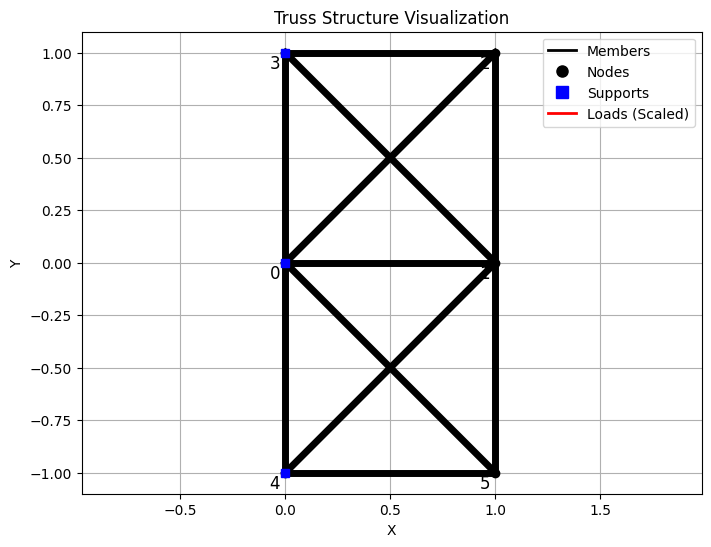

In [535]:
ts_opt.visualize_truss()

In [536]:
member_areas = [member.A for member in ts_opt.members]
V_0 = ts_opt.total_volume(member_areas)
print(f"Initial total volume: {V_0}")

Initial total volume: 6.328427124746191


In [537]:
ts_opt.generate_discretization(n_qubits_per_member=10,
                               binary_representation='range',
                            #    lower_lim=-4e5, upper_lim=4e5)
                            lower_lim=-10e5, upper_lim=10e5)

TrussStructureOptimization: Generating member area inverse polynomials.


In [538]:
ts_opt.generate_objective(penalty_weight_joints=1e-3, target_volume=V_0, penalty_weight_volume=1e3)

Node 0
Node 1
	Residual force in x-direction: - 977.517106549365 q_0 q'''''''''''_0 - 1955.03421309873 q_1 q'''''''''''_0 - 3910.06842619746 q_2 q'''''''''''_0 - 7820.13685239492 q_3 q'''''''''''_0 - 15640.2737047898 q_4 q'''''''''''_0 - 31280.5474095797 q_5 q'''''''''''_0 - 62561.0948191593 q_6 q'''''''''''_0 - 125122.189638319 q_7 q'''''''''''_0 - 250244.379276637 q_8 q'''''''''''_0 - 500488.758553275 q_9 q'''''''''''_0 - 691.208974766909 q'''''_0 q''''''''''''''''_0 - 1382.41794953382 q'''''_1 q''''''''''''''''_0 - 2764.83589906763 q'''''_2 q''''''''''''''''_0 - 5529.67179813527 q'''''_3 q''''''''''''''''_0 - 11059.3435962705 q'''''_4 q''''''''''''''''_0 - 22118.6871925411 q'''''_5 q''''''''''''''''_0 - 44237.3743850821 q'''''_6 q''''''''''''''''_0 - 88474.7487701643 q'''''_7 q''''''''''''''''_0 - 176949.497540329 q'''''_8 q''''''''''''''''_0 - 353898.995080657 q'''''_9 q''''''''''''''''_0 - 691.208974766909 q'''''''''_0 q''''''''''''''''''''_0 - 1382.41794953382 q'''''''''_1 q'''''

In [539]:
len(ts_opt.poly.variables)

121

In [540]:
annealing_solver_gpu.solve_qubo_problem(ts_opt)

Number of solutions: 1


In [541]:
best_solution, solutions = ts_opt.analyze_results()

Node 0
Node 1
	Residual force in x-direction: -23603.564623076003
	Residual force in y-direction:  24979.03557242744
Node 2
	Residual force in x-direction: -8308.89540566958
	Residual force in y-direction:  0.0
Node 3
Node 4
Node 5
	Residual force in x-direction: -5740.849828298553
	Residual force in y-direction:  52661.670942668046
Best solution (minimum objective):
Objective: 4059742.0532680065
Complementary Energy: 0.6725740318826896
Volume: 3.414213562373095
Joint Residuals (squared): 4056327167.1316013
Member Forces: [23949.16911045945, 0.0, 8308.89540566958, -0.0, 0.0, 0.0, -0.0, -171554.2521994135, -124633.431085044, -488.75855327467434, 250733.137829912]
Member Stresses: [47898.3382209189, 2932.551319648046, 16617.79081133916, -1000000.0, 661779.0811339198, 239491.69110459439, -1000000.0, -343108.504398827, -249266.862170088, -977.5171065493487, 501466.275659824]
Member Areas: [0.5, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.5, 0.5]


Max Area: 0.5


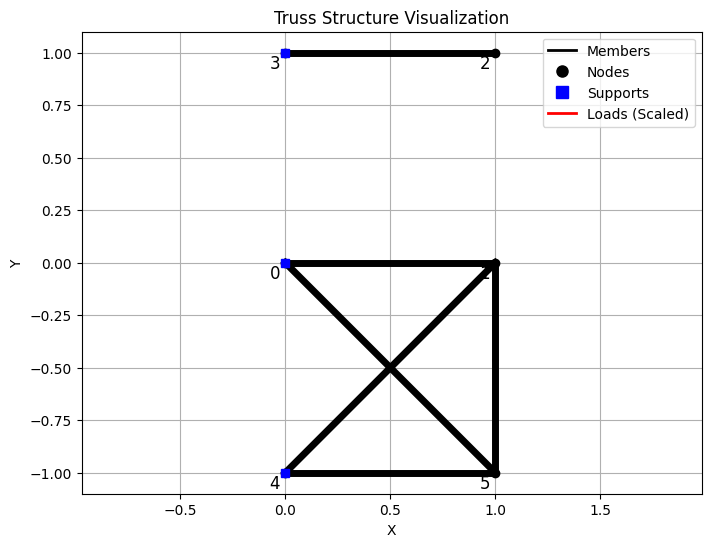

In [542]:
ts_opt.set_member_areas(best_solution['member_areas'])
ts_opt.visualize_truss()

In [543]:
def create_reference(ts_opt, best_solution):
    ts_ref = TrussStructure()

    nodes_ref = {}
    for i_member, member_area in enumerate(best_solution['member_areas']):
        if member_area > 0:
            member_nodes = (ts_opt.members[i_member].node_id_0, ts_opt.members[i_member].node_id_1)
            if member_nodes[0] not in nodes_ref:
                ts_ref.add_node(member_nodes[0], ts_opt.members[i_member].get_coords(0))
            if member_nodes[1] not in nodes_ref:
                ts_ref.add_node(member_nodes[1], ts_opt.members[i_member].get_coords(1))
            ts_ref.add_member(member_nodes[0], member_nodes[1], A=member_area , E=2e11, member_id=i_member)

    ts_ref.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1
    if 0 in ts_ref.nodes:
        ts_ref.add_support(0, True, True)  # Fixed support at Node 0
    if 3 in ts_ref.nodes:
        ts_ref.add_support(3, True, True)  # Fixed support at Node 3
    if 4 in ts_ref.nodes:
        ts_ref.add_support(4, True, True)
    # ts_ref.visualize_truss()
    return ts_ref

In [544]:
def compare_to_reference(ts_opt, best_solution):
    ts_ref = create_reference(ts_opt, best_solution)
    member_forces, compliance = ts_ref.compute_member_forces()
    rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
    print('Compliance:')
    print('===========')
    print(f'  Reference: {compliance:.8e}')
    print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
    print(f'  Rel. Diff: {rel_error_compliance:.2e}')
    print('Force:')
    print('======')
    rel_error_force_list = []
    for i_member_ref, member in enumerate(ts_ref.members):
        i_member = member.member_id
        rel_error_force = abs((member_forces[i_member_ref]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member_ref])
        print(f'  Member {i_member}:')
        print(f'    Reference: {member_forces[i_member_ref]:.8e}')
        print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
        print(f'    Rel. Diff: {rel_error_force:.2e}')
        rel_error_force_list.append(rel_error_force)

    return compliance, rel_error_compliance, member_forces, rel_error_force_list

In [545]:
def set_real_number_range(problem, iteration, member_stresses_sol_hist, best_sample, min_range):
    print(" Adjust real number representations. ".center(80, '-'))
    n_qubits_per_member = problem.n_qubits_per_member
    n_members = problem.n_members
    n_qubits = n_qubits_per_member * n_members

    a = member_stresses_sol_hist[iteration]
    a_prev = member_stresses_sol_hist[iteration-1]
    a_min = problem.a_min
    a_max = problem.a_max

    # Convert SampleSet to bit array with correct bitmapping
    bit_dict = best_sample
    # print(f'Bit dict: {bit_dict}\n')
    ordered_keys = list(range(n_qubits))
    # bit_array = [bit_dict[k] for k in ordered_keys]
    # print(f"Bit array: {bit_array}\n")
    bit_array = [int(best_sample[k]) for k in best_sample]

    c = 0.8
    for i_member in range(n_members):
        print(f"Member {i_member}:")
        start = i_member * n_qubits_per_member
        end = (i_member + 1) * n_qubits_per_member
        qubits = bit_array[start:end]
        # delta = max(a_max[node] - a_min[node], min_range)
        delta = a_max[i_member] - a_min[i_member]
        print(f"\tCurrent range: [{a_min[i_member]}, {a_max[i_member]}], ({delta})")
        print(f"\t{a_prev[i_member]} -> {a[i_member]}")

        # Save old range
        old_min = a_min[i_member]
        old_max = a_max[i_member]

        # Restrict the range of a_min and a_max based on the previous iteration
        if delta > min_range:
            if a[i_member] < a_prev[i_member]:
                # a_max[node] = a_prev[node]
                a_max[i_member] = a_max[i_member] + c*(a_prev[i_member] - a_max[i_member]) # Relaxed version
                print("\tLowering upper bound.")
            elif a[i_member] > a_prev[i_member]:
                # a_min[node] = a_prev[node]
                a_min[i_member] = a_min[i_member] + c*(a_prev[i_member] - a_min[i_member]) # Relaxed version
                print("\tRaising lower bound.")
            elif a[i_member] == a_prev[i_member]:
                # a_min[node] = a_min[node] + delta * c
                # a_max[node] = a_max[node] - delta * c
                a_min[i_member] = a_min[i_member] - (a_min[i_member]-a[i_member]) * c
                a_max[i_member] = a_max[i_member] - (a_max[i_member]-a[i_member]) * c
                print("\tShrinking range.")


        # Expand range if all qubits at a node are 1 or 0
        if all(q == 1 for q in qubits):
            print(f"\tAll qubits are 1, expanding range in positive direction.")
            a_max[i_member] += 0.05 * delta
        elif all(q == 0 for q in qubits):
            print(f"\tAll qubits are 0, expanding range in negative direction.")
            a_min[i_member] -= 0.05 * delta

        # Enforce minimum range
        if a_max[i_member] - a_min[i_member] < min_range:
            print(f"\tRange too small, enforcing minimum range of {min_range}.")
            mid = 0.5 * (a_max[i_member] + a_min[i_member])
            a_min[i_member] = mid - 0.5 * min_range
            a_max[i_member] = mid + 0.5 * min_range

        if old_min != a_min[i_member] or old_max != a_max[i_member]:
            print(f"\tUpdated range: [{a_min[i_member]}, {a_max[i_member]}], ({a_max[i_member] - a_min[i_member]})")

    print("Updated a_min and a_max for all nodes:")
    print("a_min:", problem.a_min)
    print("a_max:", problem.a_max)

In [546]:
penalty_weight = 1e1
m_lambda = 2
min_range = 1e-5
tol_member_stresses = 1e-6
max_iteration = 50
histories = {
    'objective': [best_solution['objective']],
    'compl_energy': [best_solution['complementary_energy']],
    'member_stresses': [best_solution['member_stresses']],
    'member_stresses_rel_change': [],
    # 'error_h1_rel': [error_h1_rel],
    # 'constraint': [constraint],
    'penalty_weight': [penalty_weight],
    # 'penalty_term': [penalty_weight * constraint],
}


histories['number_representation_range'] = {
    'a_min': [ts_opt.a_min.copy()],
    'a_max': [ts_opt.a_max.copy()],
}

# rel_error_compliance, rel_error_force_list = compare_to_reference(ts_opt, best_solution)
# histories['rel_error_compliance'] = [rel_error_compliance]
# histories['rel_error_force_list'] = [rel_error_force_list]

iteration = 0
# Itetarively solve the problem while increasing the penalty weight
while iteration < max_iteration:
    iteration += 1
    print(f' Iteration {iteration} '.center(80, '='))

    # Set penalty weight depending on previous constraint violation
    print(" Update the penalty weight. ".center(80, '-'))
    penalty_weight *= m_lambda
    penalty_weight = min(penalty_weight, 1e12)
    ts_opt.update_penalty_weight_in_objective(penalty_weight_joints=penalty_weight, penalty_weight_volume=1e3, target_volume=V_0)
    # self.histories['penalty_weight'].append(penalty_weight)

    # Real number representation range update
    if iteration > 1 and ts_opt.binary_representation == 'range':
        set_real_number_range(ts_opt, iteration - 1, histories['member_stresses'], ts_opt.results[0].values, min_range)

    print(" Update the objective. ".center(80, '-'))
    # Update nodal force polys
    ts_opt.update_member_stress_polys()
    ts_opt.update_member_area_inv_polys()

    # Regeneate QUBO formulation
    ts_opt.generate_objective(penalty_weight_joints=penalty_weight, penalty_weight_volume=1e3, target_volume=V_0)

    # Check if all qubits are still present in the problem
    # n_bits_current = ts.binary_quadratic_model.num_logical_vars
    # if n_bits_current != n_bits:
    #     print(f"Missing qubits. Exiting.")
    #     break


    # Solve problem
    annealing_solver_gpu.solve_qubo_problem(ts_opt)

    best_solution, solutions = ts_opt.analyze_results()

    # rel_error_compliance, rel_error_force_list = compare_to_reference(ts_opt, best_solution)

    histories['objective'].append(best_solution['objective'])
    # Complementary energy
    histories['compl_energy'].append(best_solution['complementary_energy'])
    # Member stresses
    member_stresses_prev = histories['member_stresses'][-1]
    histories['member_stresses'].append(best_solution['member_stresses'])
    member_stresses_magnitude = np.linalg.norm(np.array(best_solution['member_stresses']), axis=0)
    member_stresses_rel_change = np.linalg.norm(
        np.array(best_solution['member_stresses']) - np.array(member_stresses_prev),
        axis=0
    ) / member_stresses_magnitude
    histories['member_stresses_rel_change'].append(member_stresses_rel_change)
    print(f"Relative change in nodal forces: {member_stresses_rel_change:.6e}")
    histories['number_representation_range']['a_min'].append(ts_opt.a_min.copy())
    histories['number_representation_range']['a_max'].append(ts_opt.a_max.copy())

    # histories['rel_error_compliance'].append(rel_error_compliance)
    # histories['rel_error_force_list'].append(rel_error_force_list)

    # Joint residuals
    # self.histories['constraint'].append(constraint)
    # print(f"Current constraint violation: {constraint:.6e}")
    # Penalty term (penalty_weight * constraint)
    # self.histories['penalty_term'].append(self.problem.penalty_weight_equilibrium * constraint)


    # Store the best sample as initial state for the next iteration
    # best_sample = self.get_best_sample_as_dict()

    # print(" Analyze solution. ".center(80, '-'))
    # nf, nf_rel_change = self.analyze_and_store_solution()

    # Terminate if relative change in nodal forces is below tolerance or maximum iterations reached
    if iteration > 1 and member_stresses_rel_change < tol_member_stresses:
        print(f"Convergence reached with relative change in nodal forces ({member_stresses_rel_change:.6e} < {tol_member_stresses:.3e}).")
        break
    if iteration == max_iteration:
        print(f"Reached maximum iterations ({max_iteration}).")

print(f" Finished after {iteration} iterations. ".center(80, '#'))

================================= Iteration 1 ==================================
-------------------------- Update the penalty weight. --------------------------
---------------------------- Update the objective. -----------------------------
Node 0
Node 1
	Residual force in x-direction: - 977.517106549365 q_0 q'''''''''''_0 - 1955.03421309873 q_1 q'''''''''''_0 - 3910.06842619746 q_2 q'''''''''''_0 - 7820.13685239492 q_3 q'''''''''''_0 - 15640.2737047898 q_4 q'''''''''''_0 - 31280.5474095797 q_5 q'''''''''''_0 - 62561.0948191593 q_6 q'''''''''''_0 - 125122.189638319 q_7 q'''''''''''_0 - 250244.379276637 q_8 q'''''''''''_0 - 500488.758553275 q_9 q'''''''''''_0 - 691.208974766909 q'''''_0 q''''''''''''''''_0 - 1382.41794953382 q'''''_1 q''''''''''''''''_0 - 2764.83589906763 q'''''_2 q''''''''''''''''_0 - 5529.67179813527 q'''''_3 q''''''''''''''''_0 - 11059.3435962705 q'''''_4 q''''''''''''''''_0 - 22118.6871925411 q'''''_5 q''''''''''''''''_0 - 44237.3743850821 q'''''_6 q''''''''''''''

Max Area: 0.5


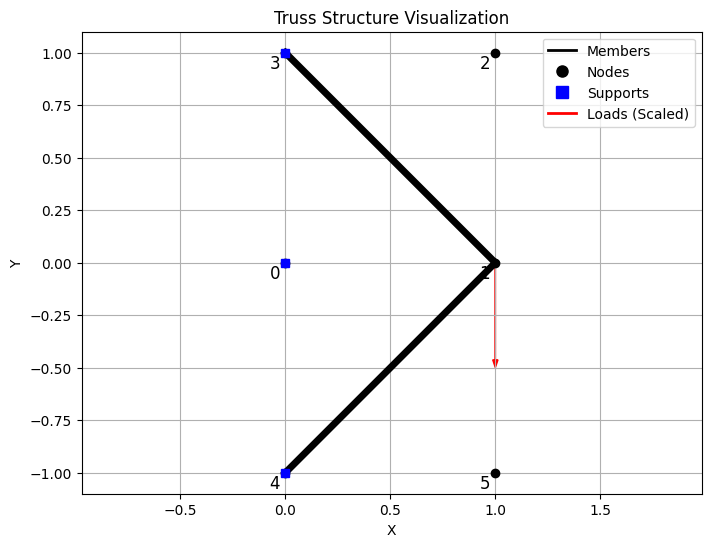

In [547]:
ts_opt.set_member_areas(best_solution['member_areas'])
ts_opt.visualize_truss()

In [548]:
compliance, rel_error_compliance, member_forces, rel_error_force_list = compare_to_reference(ts_opt, best_solution)

Compliance: 0.14142135623730953
Compliance:
  Reference: 1.41421356e-01
  Solution 1.41370535e-01
  Rel. Diff: 3.59e-04
Force:
  Member 5:
    Reference: 7.07106781e+04
    Solution 7.06827399e+04
    Rel. Diff: 3.95e-04
  Member 9:
    Reference: -7.07106781e+04
    Solution -7.07132000e+04
    Rel. Diff: 3.57e-05


In [549]:
from matplotlib import pyplot as plt

In [550]:
print(compliance)

0.14142135623730953


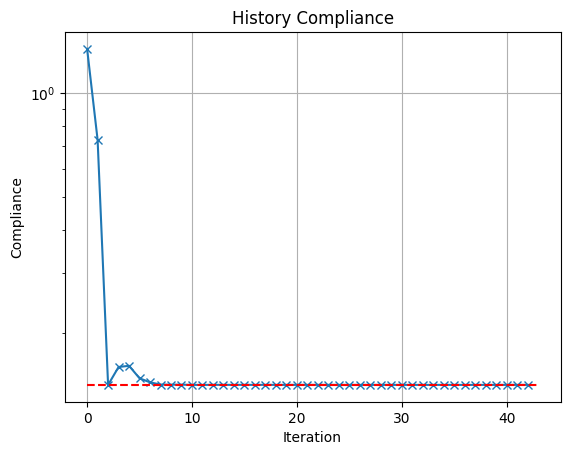

In [551]:
plt.plot(np.array(histories['compl_energy'])*2, marker='x',label='Compliance')
plt.hlines(compliance, 0, len(histories['compl_energy']), colors='r', linestyles='dashed', label='Reference')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Compliance")
plt.title("History Compliance")
plt.grid(True)
plt.show()

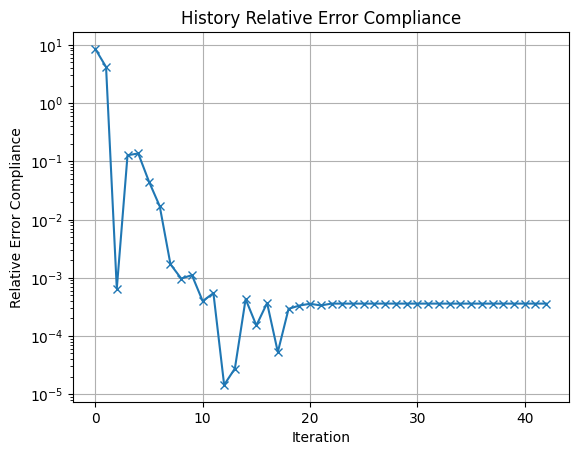

In [552]:
rel_error_compliance = abs((np.array(histories['compl_energy'])*2)-compliance)/abs(compliance)
plt.plot(rel_error_compliance, marker ='x')
plt.yscale('log')

plt.xlabel("Iteration")
plt.ylabel("Relative Error Compliance")
plt.title("History Relative Error Compliance")
plt.grid(True)
plt.show()

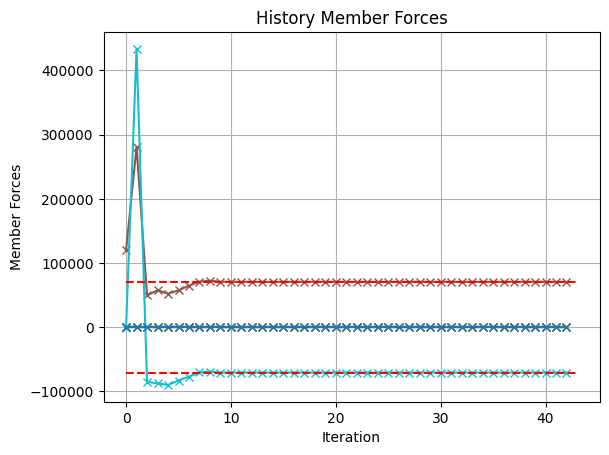

In [553]:
plt.plot(np.array(histories['member_stresses'])*best_solution['member_areas'], marker='x', label='Member Forces')
plt.hlines([force for force in member_forces.values()], 0, len(histories['member_stresses']), colors='r', linestyles='dashed', label='Reference')
plt.xlabel("Iteration")
plt.ylabel("Member Forces")
plt.title("History Member Forces")
plt.grid(True)
plt.show()

In [554]:
forces_ref = [force for force in member_forces.values()]
print(forces_ref)

[np.float64(70710.67811865476), np.float64(-70710.67811865476)]


In [555]:
force_history = np.array(histories['member_stresses'])*best_solution['member_areas']
non_zero_force_history = []
for force_state in force_history:
    # print(force_state)
    # print([force for force in force_state if abs(force) > 0.])
    non_zero_force_history.append([force for force in force_state if abs(force) > 0.])

print(non_zero_force_history)

[[np.float64(119745.84555229719), np.float64(-488.75855327467434)], [np.float64(281036.1681329423), np.float64(433528.8367546431)], [np.float64(49519.22020316691), np.float64(-85131.80236763625)], [np.float64(57550.53132784668), np.float64(-87553.13995121013)], [np.float64(52196.610479895935), np.float64(-89926.47533042588)], [np.float64(57485.706207354124), np.float64(-83073.93099624931)], [np.float64(64720.41959514402), np.float64(-76994.92358343664)], [np.float64(70976.30556951668), np.float64(-70563.42433914705)], [np.float64(72395.77590947742), np.float64(-69025.7383375475)], [np.float64(70755.69087902407), np.float64(-70743.90099291348)], [np.float64(70716.50395953182), np.float64(-70676.8037039297)], [np.float64(70657.86993333457), np.float64(-70725.01309568401)], [np.float64(70724.08090560877), np.float64(-70698.29189766514)], [np.float64(70728.2602560173), np.float64(-70695.04249979346)], [np.float64(70686.89298174829), np.float64(-70704.05942394376)], [np.float64(70730.957802

In [556]:
relative_errors_1 = []
relative_errors_2 = []
for values in non_zero_force_history:
    relative_errors_1.append(abs(values[0] - forces_ref[0]) / abs(forces_ref[0]))
    relative_errors_2.append(abs(values[1] - forces_ref[1]) / abs(forces_ref[1]))

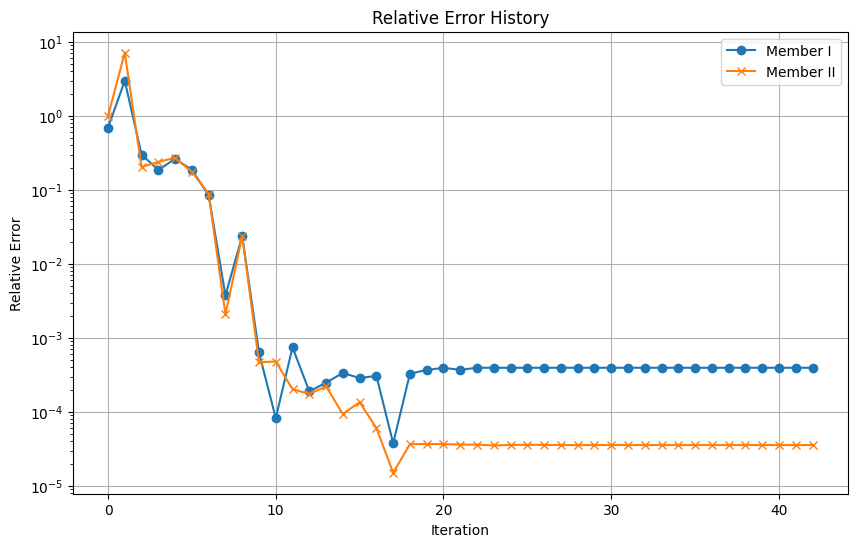

In [557]:
# Plotting the relative errors
plt.figure(figsize=(10, 6))
plt.plot(relative_errors_1, label="Member I", marker='o')
plt.plot(relative_errors_2, label="Member II", marker='x')
plt.yscale('log')
# Adding labels, title, and legend
plt.xlabel("Iteration")
plt.ylabel("Relative Error")
plt.title("Relative Error History")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()